In [1]:
import pandas as pd
import numpy as np
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import precision_recall_curve, average_precision_score
from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("../data/week1_features.csv")
df.columns = df.columns.str.replace('[', '_', regex=False).str.replace(']', '_', regex=False).str.replace(' ', '_', regex=False)

feature_cols = [col for col in df.columns if 'roll' in col]
X = df[feature_cols]
y = df["Machine_failure"]
print("Class distribution:", y.value_counts().to_dict())

Class distribution: {0: 9661, 1: 339}


In [3]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42)

# SMOTE on training only
smote = SMOTE(random_state=42)
X_resampled, y_resampled = smote.fit_resample(X_train, y_train)

model = lgb.LGBMClassifier(n_estimators=100, random_state=42, verbose=-1)
model.fit(X_resampled, y_resampled)
print("Model trained!")

Model trained!


In [4]:
# Predict probabilities
y_proba = model.predict_proba(X_test)[:, 1]
print("Probabilities sample:", y_proba[:5])

Probabilities sample: [0.0350447  0.0251859  0.62640604 0.00216566 0.01032577]


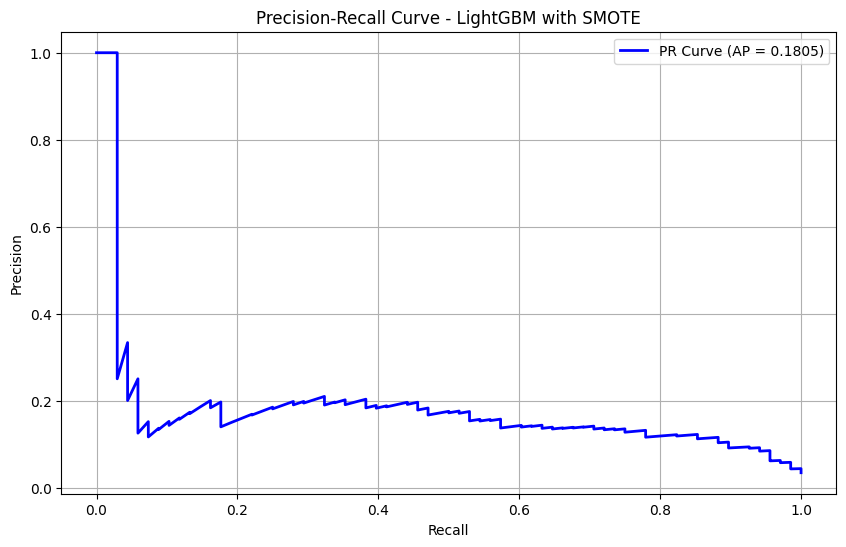

Average Precision Score: 0.1805


In [5]:
# Precision Recall Curve
precision, recall, thresholds = precision_recall_curve(y_test, y_proba)
avg_precision = average_precision_score(y_test, y_proba)

plt.figure(figsize=(10, 6))
plt.plot(recall, precision, color='blue', lw=2, label=f'PR Curve (AP = {avg_precision:.4f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - LightGBM with SMOTE')
plt.legend()
plt.grid(True)
plt.savefig("pr_curve.png")
plt.show()

print(f"Average Precision Score: {avg_precision:.4f}")